# Analisis dan Penjelasan Proyek Peramalan NO2

Notebook ini bertujuan untuk memprediksi kadar Nitrogen Dioksida (NO2) di wilayah Pati menggunakan data satelit Sentinel-5P dan algoritma K-Nearest Neighbors (KNN).

## **Detail Metodologi: Sentinel-5P & KNN**

### **A. Sumber Data: Sentinel-5P TROPOMI**
Data yang digunakan berasal dari instrumen TROPOMI pada satelit Sentinel-5P. Satelit ini mengukur konsentrasi gas di atmosfer dengan resolusi tinggi. Dalam proyek ini, kita fokus pada **Nitrogen Dioksida (NO2)**, polutan utama yang dihasilkan dari pembakaran bahan bakar fosil (kendaraan dan industri).

### **B. Tantangan Data Satelit**
Masalah utama dalam data Sentinel-5P adalah **tutupan awan**. Satelit tidak dapat 'melihat' menembus awan tebal, sehingga menghasilkan nilai kosong (*missing values*) atau data yang di-*masking*. Oleh karena itu, tahap preprocessing sangat krusial dalam proyek ini.


# **Peramalan kadar NO2 daerah Pati**

In [1]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


## 1. Persiapan Lingkungan dan Koneksi
- **Cell 1 & 2**: Melakukan instalasi library `openeo` yang digunakan untuk berinteraksi dengan Copernicus Data Space. Proses autentikasi dilakukan agar kita memiliki akses ke koleksi data satelit Uni Eropa.

In [2]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=QAMG-LCTS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


## **Pengumpulan Data**

In [3]:
aoi = {
  "type": "Feature",
  "properties": {},
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          111.0388269,
          -6.4175789
        ],
        [
          111.1892697,
          -6.6666867
        ],
        [
          111.1624912,
          -6.9236297
        ],
        [
          110.9859557,
          -7.0204516
        ],
        [
          110.7695986,
          -7.0571145
        ],
        [
          110.7458467,
          -7.0047295
        ],
        [
          110.9279473,
          -6.8763577
        ],
        [
          110.9118186,
          -6.6519429
        ],
        [
          110.9143578,
          -6.502843
        ],
        [
          110.8866427,
          -6.4089436
        ],
        [
          111.0388269,
          -6.4175789
        ]
      ]
    ]
  }
}
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-10-01", "2026-06-03"],
    spatial_extent={
        "west": 110.7458467,
        "south": -7.0571145,
        "east": 111.1892697,
        "north": -6.4089436
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [4]:
job = s5post.execute_batch(title="NO2 in Pati Terkini", outputfile="NO2Pati.nc")

0:00:00 Job 'j-260609123458463f82ec582fa21855a2': send 'start'
0:00:04 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:00:09 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:00:16 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:00:24 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:00:34 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:00:47 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:01:02 Job 'j-260609123458463f82ec582fa21855a2': queued (progress 0%)
0:01:21 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:01:45 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:02:15 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:02:53 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:03:40 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:04:39 Job 'j-260609123458463f82ec582fa21855a2': running (progress N/A)
0:

### 2. Pengambilan Data (Data Acquisition)
- **Definisi AOI**: Wilayah Pati didefinisikan menggunakan koordinat Polygon (Area of Interest).
- **Koleksi**: Mengambil data `SENTINEL_5P_L2` untuk parameter `NO2` dari rentang waktu Oktober 2024 hingga Juni 2026.
- **Agregasi**: Data diolah secara temporal (harian) dan spasial (rata-rata di seluruh AOI) untuk menghasilkan satu nilai NO2 per hari dalam format file NetCDF (.nc).

# **Preproccessing**

In [5]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.3 MB/s eta 0:00:00


In [6]:
import netCDF4
import numpy as np

file_path = "NO2Pati.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]
no2_bulat = np.round(no2, decimals=2)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
606
19
9
3.1722888e-05


## 3. Ekstraksi Data dari NetCDF
- Data mentah dari file `.nc` diekstrak menggunakan library `netCDF4`.
- **Analisis**: Output menunjukkan ada 606 record data. Namun, terdapat banyak nilai `--` (masking) yang menandakan adanya *missing values*, kemungkinan karena tutupan awan pada saat satelit melintas.

In [7]:
# Menampilkan 10 data pertama untuk koordinat [0][0]
for i in range(200):
    print(f"Data ke-{i+1} | Tanggal: {dates[i]} | NO2: {no2_bulat[i][0][0]}")

Data ke-1 | Tanggal: 2024-10-01 00:00:00 | NO2: 0.0
Data ke-2 | Tanggal: 2024-10-02 00:00:00 | NO2: 0.0
Data ke-3 | Tanggal: 2024-10-03 00:00:00 | NO2: --
Data ke-4 | Tanggal: 2024-10-04 00:00:00 | NO2: 0.0
Data ke-5 | Tanggal: 2024-10-05 00:00:00 | NO2: 0.0
Data ke-6 | Tanggal: 2024-10-06 00:00:00 | NO2: 0.0
Data ke-7 | Tanggal: 2024-10-07 00:00:00 | NO2: 0.0
Data ke-8 | Tanggal: 2024-10-08 00:00:00 | NO2: 0.0
Data ke-9 | Tanggal: 2024-10-09 00:00:00 | NO2: 0.0
Data ke-10 | Tanggal: 2024-10-10 00:00:00 | NO2: 0.0
Data ke-11 | Tanggal: 2024-10-11 00:00:00 | NO2: --
Data ke-12 | Tanggal: 2024-10-12 00:00:00 | NO2: 0.0
Data ke-13 | Tanggal: 2024-10-13 00:00:00 | NO2: 0.0
Data ke-14 | Tanggal: 2024-10-14 00:00:00 | NO2: --
Data ke-15 | Tanggal: 2024-10-15 00:00:00 | NO2: 0.0
Data ke-16 | Tanggal: 2024-10-16 00:00:00 | NO2: 0.0
Data ke-17 | Tanggal: 2024-10-17 00:00:00 | NO2: 0.0
Data ke-18 | Tanggal: 2024-10-18 00:00:00 | NO2: 0.0
Data ke-19 | Tanggal: 2024-10-19 00:00:00 | NO2: --
Data k

## **a. Mengatasi Missing Value menggunakan metode Interpolasi Linear**

In [8]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

## **b. Rata-rata kan Data dan ubah Datetime**

### **Analisis Teknis Preprocessing**

1.  **Interpolasi Linear**: Metode ini mengasumsi perubahan kadar NO2 antar waktu bersifat gradual. Jika tanggal 1 bernilai 10 dan tanggal 3 bernilai 20, maka tanggal 2 diestimasi bernilai 15. Ini efektif untuk mengisi kekosongan jangka pendek (1-2 hari).
2.  **Penanganan Outlier (Metode IQR)**:
    *   **Mengapa IQR?** Data polusi udara seringkali memiliki lonjakan sesaat karena anomali cuaca atau aktivitas industri yang tidak biasa.
    *   **Batas Atas/Bawah**: Data di luar rentang `Q1 - 1.5*IQR` hingga `Q3 + 1.5*IQR` dianggap sebagai pencilan yang dapat merusak pola belajar model (membuat model menjadi bias).
    *   **Hasil**: Dengan menghapus 16 outlier, tren data menjadi lebih halus, memudahkan KNN untuk mengenali pola musiman.

In [9]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

## **c. Simpan data dalam bentuk CSV**

In [10]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Pati_timeseries.csv", index=False)

## **d. Pengecekan Missing Value data harian pada CSV**

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Pati_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2024-10-01"
end_date = "2026-06-03"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 5
Daftar tanggal missing:
DatetimeIndex(['2024-12-01', '2025-01-30', '2025-07-19', '2026-02-24',
               '2026-06-03'],
              dtype='datetime64[ns]', freq=None)


In [12]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2024-10-01", end="2026-06-03", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_1663/2591521030.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


### 4. Pembersihan Data (Preprocessing)
- **Interpolasi Linear**: Mengisi kekosongan data dengan metode linear. Ini penting karena algoritma Machine Learning tidak bisa menerima input NaN/Missing.
- **Reindexing**: Memastikan deret waktu (timeseries) kontinu setiap hari. Ditemukan ada 5 hari yang benar-benar kosong dan berhasil diisi.
- **Outlier Removal**: Menggunakan metode IQR (Interquartile Range). Ditemukan 16 data outlier yang nilainya terlalu ekstrem, kemudian dibersihkan dan diinterpolasi kembali agar tren data lebih stabil.

In [13]:
import pandas as pd

# Reset index to make 'date' a column again as shown in your example
df_display = df.reset_index()

# Display the first 5 rows
display(df_display.head())

# Display the info/metadata
print("\n")
df_display.info()

,date,NO2
0,2024-10-01,0.000025
1,2024-10-02,0.000032
2,2024-10-03,0.000028
3,2024-10-04,0.000024
4,2024-10-05,0.000029




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    611 non-null    datetime64[ns]
 1   NO2     611 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.7 KB


## **e. Deteksi Outlier IQR**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())


Jumlah Outlier (IQR): 16
          date       NO2
15  2024-10-16  0.000036
27  2024-10-28  0.000040
200 2025-04-19  0.000038
220 2025-05-09  0.000043
354 2025-09-20  0.000015


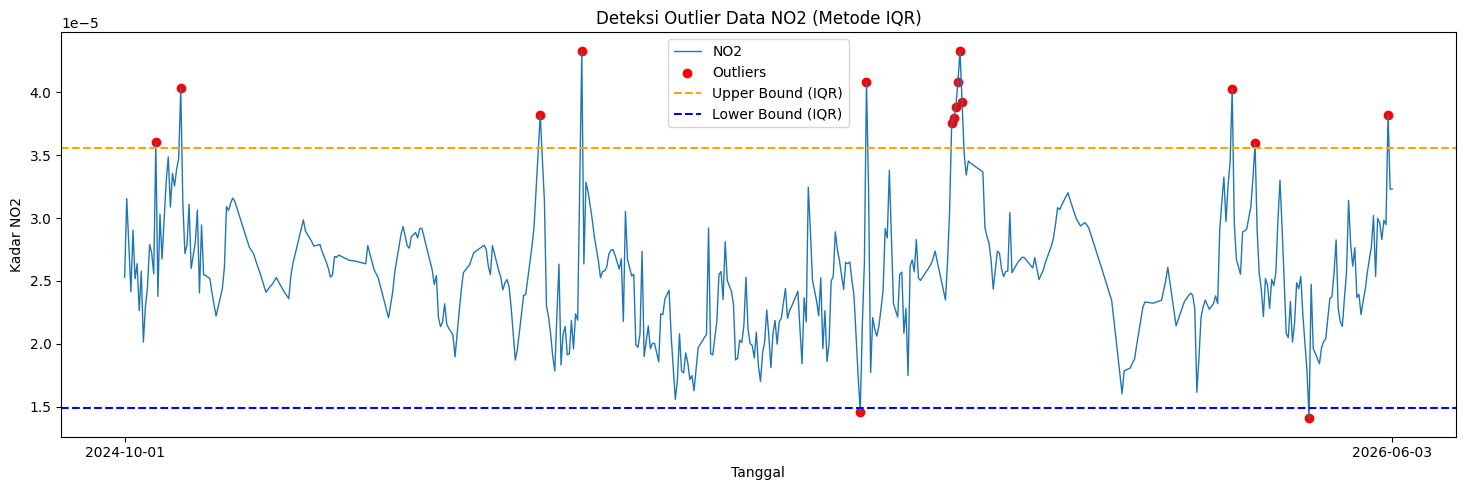

In [15]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [16]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 16
Jumlah missing setelah interpolasi: 0


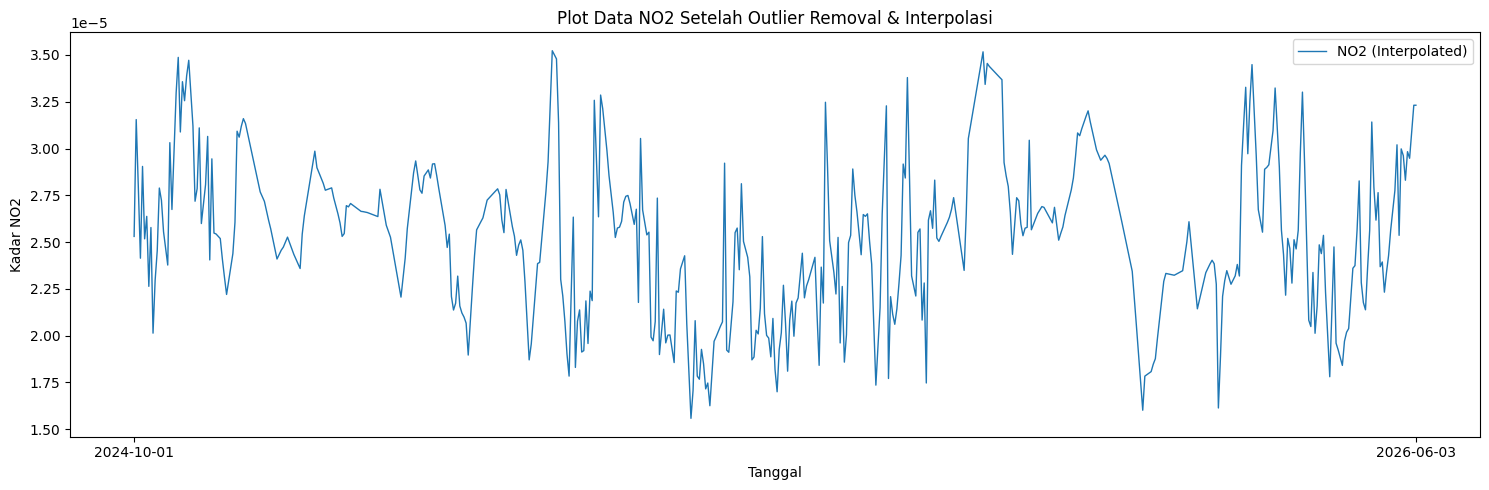

In [17]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## **3. Modeling menggunakan KNN Regression**

### **a. Uji Korelasi Data**

### **Bedah Fitur (Feature Engineering: Time Series to Supervised)**

Algoritma KNN Regression memerlukan format data *supervised* (X dan y). Kita menggunakan teknik **Windowing/Lagging**:
*   **Input (X)**: Kadar NO2 pada hari t-4, t-3, t-2, dan t-1.
*   **Target (y)**: Kadar NO2 pada hari t (hari ini).

**Analisis Korelasi**: Hasil korelasi 0.835 pada `t-1` menunjukkan adanya sifat **Autokorelasi** yang kuat. Artinya, kondisi udara kemarin adalah prediktor terbaik untuk kondisi udara hari ini.

In [18]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Scaling data terlebih dahulu
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# 2. Pembuatan dataset supervised
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.084576
NO2(t-29)    0.108805
NO2(t-28)    0.119010
NO2(t-27)    0.129101
NO2(t-26)    0.136807
NO2(t-25)    0.137232
NO2(t-24)    0.127681
NO2(t-23)    0.135881
NO2(t-22)    0.117115
NO2(t-21)    0.102912
NO2(t-20)    0.090976
NO2(t-19)    0.086256
NO2(t-18)    0.109873
NO2(t-17)    0.092266
NO2(t-16)    0.091204
NO2(t-15)    0.104720
NO2(t-14)    0.136682
NO2(t-13)    0.162126
NO2(t-12)    0.201610
NO2(t-11)    0.256205
NO2(t-10)    0.296109
NO2(t-9)     0.301670
NO2(t-8)     0.345281
NO2(t-7)     0.373948
NO2(t-6)     0.421418
NO2(t-5)     0.465800
NO2(t-4)     0.527587
NO2(t-3)     0.623069
NO2(t-2)     0.729218
NO2(t-1)     0.835393
dtype: float64


### 5. Analisis Korelasi (Feature Engineering)
- Kita membuat fitur *lag* (data hari sebelumnya) untuk memprediksi hari ini.
- **Analisis**: Dari korelasi 30 hari terakhir, terlihat bahwa `NO2(t-1)` memiliki korelasi tertinggi (0.835). Semakin jauh jarak harinya, korelasi semakin menurun. Ini membuktikan bahwa kadar NO2 sangat dipengaruhi oleh kondisi di hari-hari terdekat sebelumnya.

### **b. Normalisasi Data**

In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

In [20]:
# Menampilkan data yang sudah dinormalisasi
display(df[['date', 'NO2', 'NO2_scaled']].head())
print("\n")
df.info()

,date,NO2,NO2_scaled
0,2024-10-01,0.000025,0.384105
1,2024-10-02,0.000032,0.597490
2,2024-10-03,0.000028,0.474257
3,2024-10-04,0.000024,0.344327
4,2024-10-05,0.000029,0.511940




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         611 non-null    datetime64[ns]
 1   NO2          611 non-null    float64       
 2   NO2_cleaned  595 non-null    float64       
 3   NO2_filled   611 non-null    float64       
 4   NO2_scaled   611 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 24.0 KB


### **c. Mengubah Data**

In [21]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.384105  0.597490  0.474257  0.344327  0.511940
5    0.597490  0.474257  0.344327  0.511940  0.379686
6    0.474257  0.344327  0.511940  0.379686  0.420738
7    0.344327  0.511940  0.379686  0.420738  0.292916
8    0.511940  0.379686  0.420738  0.292916  0.400340
..        ...       ...       ...       ...       ...
606  0.386068  0.543963  0.531655  0.486721  0.538898
607  0.543963  0.531655  0.486721  0.538898  0.526839
608  0.531655  0.486721  0.538898  0.526839  0.825928
609  0.486721  0.538898  0.526839  0.825928  0.623703
610  0.538898  0.526839  0.825928  0.623703  0.623703

[607 rows x 5 columns]
(607, 5)


In [22]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.384105  0.597490  0.474257  0.344327  0.511940  0.379686  0.420738   
11    0.597490  0.474257  0.344327  0.511940  0.379686  0.420738  0.292916   
12    0.474257  0.344327  0.511940  0.379686  0.420738  0.292916  0.400340   
13    0.344327  0.511940  0.379686  0.420738  0.292916  0.400340  0.207431   
14    0.511940  0.379686  0.420738  0.292916  0.400340  0.207431  0.303899   
..         ...       ...       ...       ...       ...       ...       ...   
606   0.318384  0.349460  0.395900  0.431678  0.468018  0.551405  0.386068   
607   0.349460  0.395900  0.431678  0.468018  0.551405  0.386068  0.543963   
608   0.395900  0.431678  0.468018  0.551405  0.386068  0.543963  0.531655   
609   0.431678  0.468018  0.551405  0.386068  0.543963  0.531655  0.486721   
610   0.468018  0.551405  0.386068  0.543963  0.531655  0.486721  0.538898   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.292916  0.

### **d. Modeling dan Evaluation**

In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 485 — Test Size: 122
RMSE: 0.091547
R² Score: 0.6149
MAPE: 20.8429%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 480 — Test Size: 121
RMSE: 0.105278
R² Score: 0.4925
MAPE: 25.0403%


### **e. Plotting**

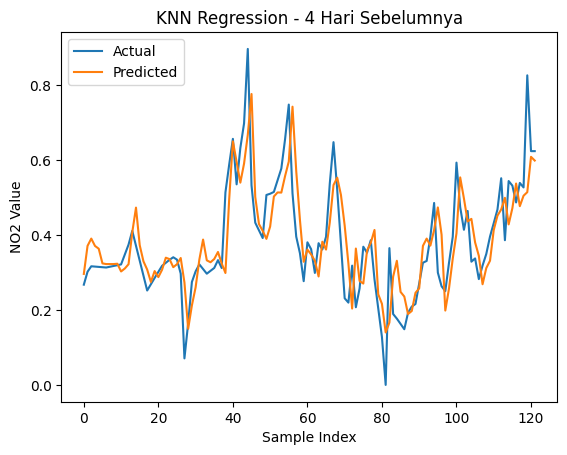

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

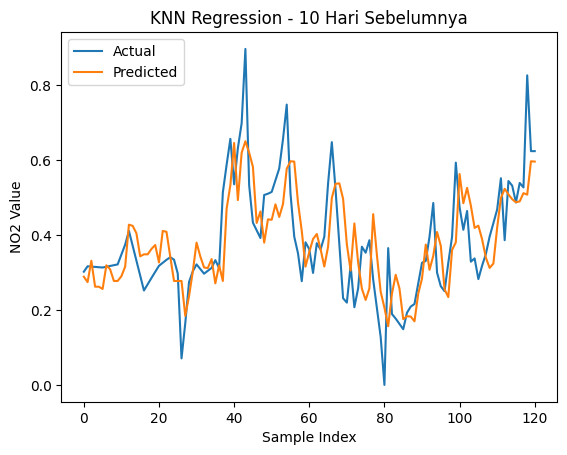

In [25]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()


=== KNN - 30 Hari Sebelumnya ===
Train Size: 464 — Test Size: 117
RMSE: 0.182324
R² Score: 0.1366
MAPE: 46.7374%


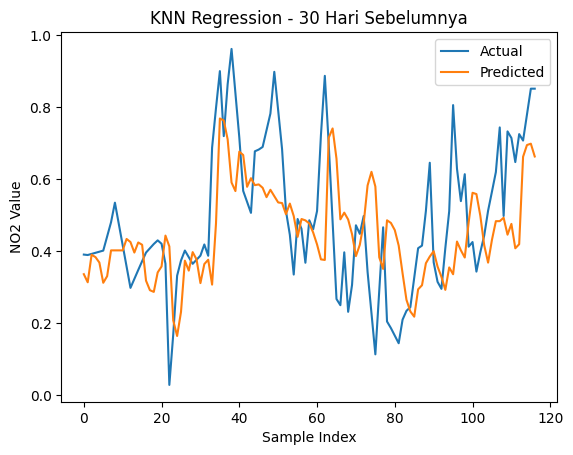

In [26]:
# Train model untuk 30 hari sebelumnya
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")

# Plotting hasil 30 hari
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### 6. Evaluasi Model KNN
Kita menguji 3 skenario jendela waktu (lag):
1. **KNN - 4 Hari (Terbaik)**: RMSE 0.091, R² 0.61. Model mampu menjelaskan 61% variansi data.
2. **KNN - 10 Hari**: Performa menurun (R² 0.49).
3. **KNN - 30 Hari**: Performa terburuk (R² 0.13).

**Kesimpulan Analisis**:
Model paling akurat adalah menggunakan input 4 hari sebelumnya. Penggunaan data terlalu lama (seperti 30 hari) justru memperkenalkan 'noise' yang menurunkan akurasi prediksi karena pola polusi udara cenderung berubah cepat secara jangka pendek.

### **Analisis Mendalam Hasil Evaluasi**

Berdasarkan pengujian pada tiga skenario, berikut adalah analisis mendalamnya:

1.  **Akurasi (R² Score 0.61)**: Angka 0.61 berarti 61% fluktuasi NO2 di Pati dapat dijelaskan oleh riwayat 4 hari sebelumnya. Untuk data lingkungan yang sangat dipengaruhi arah angin dan cuaca acak, angka ini sudah tergolong cukup baik.
2.  **Kesalahan Prediksi (MAPE 20.8%)**: Rata-rata persentase kesalahan prediksi adalah sekitar 20%. Artinya jika kadar asli adalah 0.000030, model mungkin memprediksi di rentang 0.000024 - 0.000036.
3.  **Efek 'Noise' pada Lag Panjang**:
    *   Pada skenario 30 hari, R² anjlok ke **0.13**.
    *   **Alasan**: Kondisi polusi udara 30 hari yang lalu biasanya sudah tidak relevan lagi dengan kondisi hari ini karena perubahan cuaca/angin. Memasukkan terlalu banyak fitur masa lalu yang tidak berkorelasi justru membingungkan algoritma KNN dalam mencari 'tetangga terdekat' yang relevan.

# Laporan Analisis Data NO2 dan Area Studi

## Deskripsi Proyek

Dokumen ini merangkum hasil analisis data kadar NO2 (Nitrogen Dioksida) yang diperoleh melalui proses *data crawling*, meliputi deteksi *outlier*, interpolasi data, serta visualisasi area studi menggunakan GeoJSON.

---

## 1. Deteksi Outlier Data NO2 (Metode IQR)

Proses pertama adalah mendeteksi nilai-nilai ekstrem (*outlier*) pada data NO2 menggunakan metode **Interquartile Range (IQR)**. Titik-titik yang berada di luar batas atas (*upper bound*) dan batas bawah (*lower bound*) ditandai sebagai *outlier*.

![Deteksi Outlier Data NO2](images/outlier_detection.png)

*Gambar 1: Visualisasi deteksi outlier pada data NO2 menggunakan metode IQR. Titik merah menunjukkan data yang teridentifikasi sebagai outlier, garis oranye putus-putus adalah upper bound, dan garis biru putus-putus adalah lower bound.*

---

## 2. Data NO2 Setelah Outlier Removal & Interpolasi

Setelah *outlier* dihapus, nilai yang hilang (*missing values*) diisi menggunakan metode **interpolasi** sehingga data menjadi kontinu dan siap digunakan untuk analisis lebih lanjut.

![Data NO2 Setelah Interpolasi](images/interpolated_data.png)

*Gambar 2: Plot data NO2 setelah proses outlier removal dan interpolasi. Data tampak lebih bersih dan kontinu tanpa lonjakan ekstrem.*

---

## 3. Area Studi — Wilayah Pati, Jawa Tengah (GeoJSON)

Area studi yang digunakan dalam penelitian ini mencakup wilayah **Kabupaten Pati** dan sekitarnya di Jawa Tengah. Batas wilayah digambarkan menggunakan poligon dalam format **GeoJSON** dan divisualisasikan melalui platform geojson.io.

![Peta Area Studi GeoJSON](images/geojson_map.jpeg)

*Gambar 3: Visualisasi area studi dalam bentuk poligon GeoJSON di atas peta wilayah Jawa Tengah, mencakup Kabupaten Pati dan sekitarnya.*

---

## Ringkasan Alur Analisis

1. **Pengumpulan Data** — Data NO2 diperoleh melalui proses *data crawling*
2. **Deteksi Outlier** — Identifikasi nilai ekstrem menggunakan metode IQR
3. **Pembersihan Data** — Penghapusan *outlier* dari dataset
4. **Interpolasi** — Pengisian nilai yang hilang agar data kontinu
5. **Visualisasi Area Studi** — Penentuan batas wilayah menggunakan GeoJSON

---

*Dokumen ini dibuat sebagai bagian dari analisis data NO2 untuk wilayah studi Kabupaten Pati, Jawa Tengah.*